# BEE 4750 Lab 2: Monte Carlo

**Name**: William Natcharian

**ID**: wrn25

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [1]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/Desktop/4750 Cloned Repositories/lab-2-Wyndter`


In [2]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [3]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [4]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

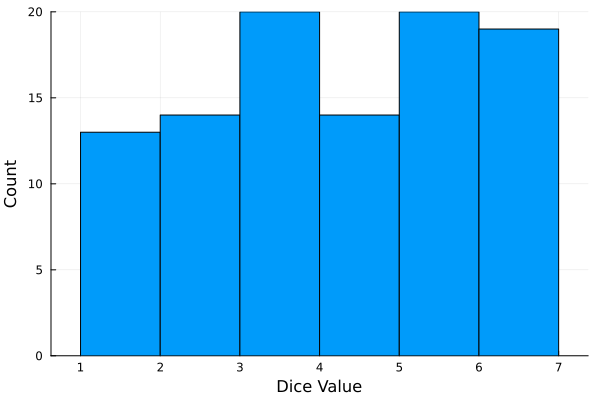

In [5]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

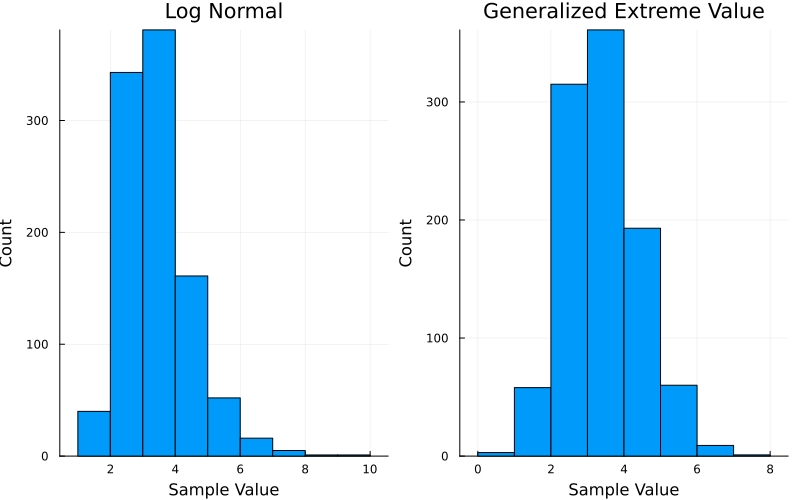

In [77]:
log_dist = LogNormal(1.2, 0.3)
log_sample = rand(log_dist, 1000)
p1 = histogram(log_sample, legend=:false, bins=10, title = "Log Normal")

gen_dist = GeneralizedExtremeValue(3, 0.9, -0.15)
gen_sample = rand(gen_dist, 1000)
p2 = histogram(gen_sample, legend=:false, bins=10, title = "Generalized Extreme Value")

plot(p1, p2, layout=(1,2), size = (800,500), )
ylabel!("Count")
xlabel!("Sample Value")

--> The graphs above show histograms of a Log Normal distribution and a Generalized Extreme Value distribution with similar ranges side-by-side. Both histograms show approximately 8 distinct boxes to display the amount of randomly generated values from those distributions which fell in each box's domain. The Log Normal distribution is skewed to the right, meaning most of its generated values are closer to the minimum value than to the maximum. While the Generalized Exreme value distribution is approximately normal, with a tiny skew to the right.

--> Coding Explanation: To plot the two distributions above, I used the same method as shown previously to plot the results of a random dice being rolled 100 times. To display the two plots side-by-side I added a "layout = (1,2)" term to my plot command.

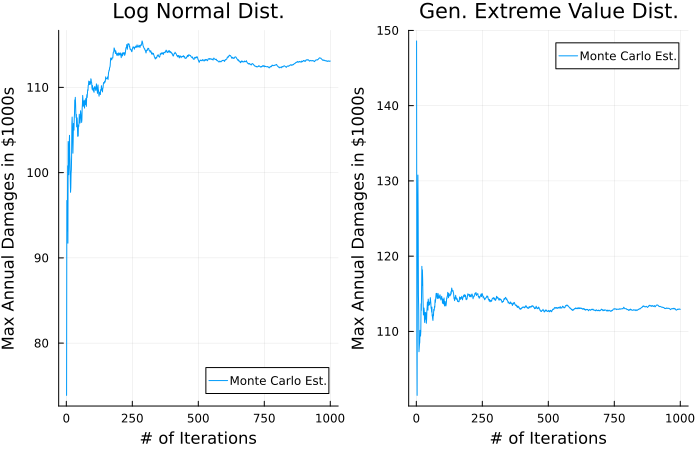

In [121]:
#putting depth damage equation into a function to simplify code down the line
function depthDamages(h, h_0, k, L)
    #Indicator function
    if h <= 0
        return 0
    end

    #calculating damages
    d = L / (1 + exp(-k*(h-h_0)))
    return d
end

#initializing array to hold damage values
damages_norm = zeros(Float64, 1000)

#finding damage for each flood depth
for i in 1:1000
    #damages[i] = log_sample[i]
    damages_norm[i] = depthDamages(log_sample[i], 3, 0.8, 200)
end

#initializing array and variables to calculate Monte Carlo Estimate for Log Normal distribution
counter = 0
mean = 0
monteCarlo_norm = zeros(Float64, 1000)

for i in 1:1000
    counter = counter + damages_norm[i]
    mean = counter / i
    monteCarlo_norm[i] = mean
end

final_monte_norm = mean

#Repeating steps for generalized extreme value distribution
damages_extr = zeros(Float64, 1000)

#finding damage for each flood depth
for i in 1:1000
    #damages[i] = log_sample[i]
    damages_extr[i] = depthDamages(gen_sample[i], 3, 0.8, 200)
end

#initializing array and variables to calculate Monte Carlo Estimate for Log Normal distribution
counter_e = 0
mean_e = 0
monteCarlo_extr = zeros(Float64, 1000)

for i in 1:1000
    counter_e = counter_e + damages_extr[i]
    mean_e = counter_e / i
    monteCarlo_extr[i] = mean_e
end

final_monte_extr = mean_e

#depthDamages(h_i, 3, 0.8, 200)

p3 = plot(1:1000, monteCarlo_norm, xlabel = "# of Iterations", ylabel = "Max Annual Damages in \$1000s", 
title = "Log Normal Dist.", label = "Monte Carlo Est.")
p4 = plot(1:1000, monteCarlo_extr, xlabel = "# of Iterations", ylabel = "Max Annual Damages in \$1000s", 
title = "Gen. Extreme Value Dist.", label = "Monte Carlo Est.")
#plot!(p3, subplot=1, [1,1000],[final_monte_norm,final_monte_norm])
#plot!(p4, subplot=1, [1,1000],[final_monte_extr,final_monte_extr])
plot(p3, p4, layout=(1,2), size = (700,450))




 

--> Description of Plot 1: The plot on the left shows the Monte Carlo Estimate of the maximum annual flood damages in \$1000s at each iteration when we simulate the maximum annual flood depth from a Log Normal distribution (with inputs of 1.2 and 0.3). We can see that at the beginning of the simulation the monte carlo method significantly underestimates the average value, then as more datapoints come in from the later iterations, the randomness is evened out over time towards a final value. The estimate after the 1000th iteration is approximately \$113,084.

--> Description of Plot 2: The plot on the right shows the Monte Carlo Estimate of the maximum annual flood damages in \$1000s at each iteration when we simulate the maximum annual flood depth from a Generalized Extreem Value distribution (with inputs of 3, 0.9, and -0.15). We can see that at the beginning of the simulation the monte carlo method significantly overestimates the average value, then as more datapoints come in from the later iterations, the randomness is evened out over time towards a final value. The estimate after the 1000th iteration is approximately \$112,939.

--> Explanation of Code: To plot these two graphs I used the same method I used to display the histograms side-by-side, by creating a layout for the subplots to go in. To calculate the values of the Monte Carlo Estimates I first plugged each randomly generated value from the two distributions into the depth damage function, and I recorded the damage cost outputs in arrays. I then used a for loop to take the average of of all the array values (for each distribution) for each iteration of the process. This resulted in the graphs you see above, where the estimate begins wildly far off, then becomes more accurate and starts to approach a final value.



In [ ]:
#Code to sort the damages by value, to find the 99% quantile for each dsitribution
sorted_norm = sort(damages_norm)
norm_quant_99 = sorted_norm[990]
sorted_extr = sort(damages_extr)
extr_quant_99 = sorted_extr[990]
@show norm_quant_99
@show extr_quant_99;

norm_quant_99 = 189.4686953688928
extr_quant_99 = 182.8330284466076


--> The code above uses the built-in Julia function to sort the arrays of damages from each flood depth by magnitude. I use this function to find the expected 99% quantile for each distribution.

## Answers to Questions:

**What are the Monte Carlo estimates of the expected value and the 99% quantile for the annual maximum damage the structure would suffer for each of these flood hazard distributions?**

--> The Monte Carlo estimate of the expected value using the Log Normal distribution is \$113,084, and the 99% quantile for this distribution is \$189,469.

--> The Monte Carlo estimate of the expected value using the Generalized Extreme Value distribution is \$112,939, and the 99% quantile for this distribution is \$182,833.

--> The expected values come from the value of the calculated mean at the 1000th iteration, and the 99% quantiles are the (0.99*N)th highest value for damages from each distribution (code for quantile calculations is shown above).

**How did you decide on your sample size?**

--> I originally started with 100 samples, but the variation was fairly high, so I opted to increase the number of iterations to 1000. This sample size took about 3 seconds to load the plots, so I chose to stop there, since the time it would take to calculate everything would continue to increase exponentially. And the sample size I landed with shows an accuracy that I am satisfied with.

**Why do you think the estimates differed or did not differ (you can also plot the depth-damage function to compare with the samples)?**

--> The estimates at the 1000th iteration differed by \$251, which is very small given that the maximum possible damage was \$200,000. However, at the beginning of the iteration process, the two estimates differed wildly. The estimate using the Log Normal distribution began much lower than the long-term value, while the Generalized Extreme Value distribution began much higher.

--> These differences make sense, given the distributions that they came from. For instance, the Log Normal distribution was skewed to the right, meaning most of the values were bunched up closer to the origin, making it more likely that a series of low values are generated for the first few iterations, causing the significant initial underestimation. Likewise, the Generalized Extreme Value distribution initially overestimates the value, which makes sense for an approximately normal distribution.

--> Otherwise, there is a \$7,000 difference between the quantiles. This can be explained since the Log Normal distribution is skewed to the right, meaning there are some very high values appearing at low frequencies. These high values most likely made the 99% quantile for the Log Normal distribution higher than the Generalized Extreme Value distribution.

**How might you decide (based on getting additional information, if needed) which distribution is “better”?**

--> The long-term estimates from both distributions are very similar, so deciding which is better depends on whether we want to underestimate or overestimate the maximum damages. 

--> For budgeting reasons, I would assume it is better to overestimate the maximum damages, so that we are always prepared for that possibility. Since both estimates are very close to one another, we can look at the large differencein quantiles to decide: 

--> Since the 99% quantile and long-term estimate for maximum annual flood damages from the Log Normal distribution is higher than those from the Generalized Extreme Value distribution, we can say that the Log Normal distribution is "better."

--> Of course, the answer also depends on which distribution actually models the maximum annual flood depth most accurately.

## References

Put any consulted sources here, including classmates you worked with/who
helped you.

--> I worked on this lab by myself and did not recieve help.